In [ ]:
import pandas as pd
df = pd.read_csv('/content/predict restuarant customer satisfaction.zip')
print(df)

      CustomerID  Age  Gender  Income VisitFrequency  AverageSpend  \
0            654   35    Male   83380         Weekly     27.829142   
1            655   19    Male   43623         Rarely    115.408622   
2            656   41  Female   83737         Weekly    106.693771   
3            657   43    Male   96768         Rarely     43.508508   
4            658   55  Female   67937        Monthly    148.084627   
...          ...  ...     ...     ...            ...           ...   
1495        2149   39    Male  114857        Monthly    163.015254   
1496        2150   37  Female  133506         Weekly    190.991911   
1497        2151   46    Male  119159        Monthly    150.088604   
1498        2152   24    Male   27970         Weekly    196.363626   
1499        2153   51    Male  148333         Weekly    171.119498   

     PreferredCuisine TimeOfVisit  GroupSize DiningOccasion  MealType  \
0             Chinese   Breakfast          3       Business  Takeaway   
1            

In [ ]:
null_values=df.isnull().sum()
print(null_values)

CustomerID              0
Age                     0
Gender                  0
Income                  0
VisitFrequency          0
AverageSpend            0
PreferredCuisine        0
TimeOfVisit             0
GroupSize               0
DiningOccasion          0
MealType                0
OnlineReservation       0
DeliveryOrder           0
LoyaltyProgramMember    0
WaitTime                0
ServiceRating           0
FoodRating              0
AmbianceRating          0
HighSatisfaction        0
dtype: int64


In [ ]:
X=df.replace({'Female':1,'Male':0,'Weekly':0,'Monthly':1,'Rarely':2,'Daily':3,'Chinese':0,'American':1,'Indian':2,'Italian':3,'Mexican':4,'Breakfast':0,'Lunch':1,'Dinner':2,'Business':0,'Casual':1,'Celebration':2,'Takeaway':0,'Dine-in':1})
print(X)

      CustomerID  Age  Gender  Income  VisitFrequency  AverageSpend  \
0            654   35       0   83380               0     27.829142   
1            655   19       0   43623               2    115.408622   
2            656   41       1   83737               0    106.693771   
3            657   43       0   96768               2     43.508508   
4            658   55       1   67937               1    148.084627   
...          ...  ...     ...     ...             ...           ...   
1495        2149   39       0  114857               1    163.015254   
1496        2150   37       1  133506               0    190.991911   
1497        2151   46       0  119159               1    150.088604   
1498        2152   24       0   27970               0    196.363626   
1499        2153   51       0  148333               0    171.119498   

      PreferredCuisine  TimeOfVisit  GroupSize  DiningOccasion  MealType  \
0                    0            0          3               0         

<ipython-input-3-2ec9de8bad99>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X=df.replace({'Female':1,'Male':0,'Weekly':0,'Monthly':1,'Rarely':2,'Daily':3,'Chinese':0,'American':1,'Indian':2,'Italian':3,'Mexican':4,'Breakfast':0,'Lunch':1,'Dinner':2,'Business':0,'Casual':1,'Celebration':2,'Takeaway':0,'Dine-in':1})


In [ ]:
df=pd.DataFrame({
    'x0':1,
    'x1':X['CustomerID'],
    'x2':X['Age'],
    'x3':X['Gender'],
    'x4':X['Income'],
    'x5':X['VisitFrequency'],
    'x6':X['AverageSpend'],
    'x7':X['PreferredCuisine'],
    'x8':X['TimeOfVisit'],
    'x9':X['GroupSize'],
    'x10':X['DiningOccasion'],
    'x11':X['MealType'],
    'x12':X['OnlineReservation'],
    'x13':X['DeliveryOrder'],
    'x14':X['LoyaltyProgramMember'],
    'x15':X['WaitTime'],
    'x16':X['ServiceRating'],
    'x17':X['FoodRating'],
    'x18':X['AmbianceRating'],
    'y':X['HighSatisfaction']

})
print(df)

      x0    x1  x2  x3      x4  x5          x6  x7  x8  x9  x10  x11  x12  \
0      1   654  35   0   83380   0   27.829142   0   0   3    0    0    0   
1      1   655  19   0   43623   2  115.408622   1   2   1    1    1    0   
2      1   656  41   1   83737   0  106.693771   1   2   6    2    1    0   
3      1   657  43   0   96768   2   43.508508   2   1   1    2    1    0   
4      1   658  55   1   67937   1  148.084627   0   0   1    0    0    0   
...   ..   ...  ..  ..     ...  ..         ...  ..  ..  ..  ...  ...  ...   
1495   1  2149  39   0  114857   1  163.015254   1   1   2    0    1    0   
1496   1  2150  37   1  133506   0  190.991911   3   1   4    1    0    0   
1497   1  2151  46   0  119159   1  150.088604   1   1   4    1    1    0   
1498   1  2152  24   0   27970   0  196.363626   3   2   6    1    1    1   
1499   1  2153  51   0  148333   0  171.119498   0   0   4    1    1    1   

      x13  x14        x15  x16  x17  x18  y  
0       1    1  43.523929    

In [ ]:
y_counts = df['y'].value_counts()
print(y_counts)

y
0    1299
1     201
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE
X = df.drop('y', axis=1)
y = df['y']
smote = SMOTE(sampling_strategy=1)
X_resampled, y_resampled = smote.fit_resample(X, y)
y_resampled_counts = y_resampled.value_counts()
print(y_resampled_counts)

y
0    1299
1    1299
Name: count, dtype: int64


In [ ]:
print(X_resampled)
print(y_resampled)

      x0    x1  x2  x3      x4  x5          x6  x7  x8  x9  x10  x11  x12  \
0      1   654  35   0   83380   0   27.829142   0   0   3    0    0    0   
1      1   655  19   0   43623   2  115.408622   1   2   1    1    1    0   
2      1   656  41   1   83737   0  106.693771   1   2   6    2    1    0   
3      1   657  43   0   96768   2   43.508508   2   1   1    2    1    0   
4      1   658  55   1   67937   1  148.084627   0   0   1    0    0    0   
...   ..   ...  ..  ..     ...  ..         ...  ..  ..  ..  ...  ...  ...   
2593   1  1632  39   0   97581   0   75.790997   0   0   3    1    1    0   
2594   1   853  19   1   88678   0  167.955125   2   1   8    2    0    0   
2595   1  1504  61   1   27118   2  100.142434   3   0   3    1    1    0   
2596   1  2075  64   0   35576   1   81.749345   1   1   6    1    0    0   
2597   1  1858  22   0  129690   0  133.170050   1   1   7    0    1    0   

      x13  x14        x15  x16  x17  x18  
0       1    1  43.523929    2  

In [ ]:
from sklearn.model_selection import train_test_split
X_train_resampled, X_test_resampled,y_train_resampled,y_test_resampled = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=30)
print("\nX_train(X_train):")
print(X_train_resampled)
print("\ny_train(y_train):")
print(y_train_resampled)
print("\nX_test(X_test):")
print(X_test_resampled)
print("\ny_test(y_test):")
print(y_test_resampled)


X_train(X_train):
      x0    x1  x2  x3      x4  x5          x6  x7  x8  x9  x10  x11  x12  \
2063   1  1005  61   0   89810   2   77.894145   2   0   1    2    1    0   
1475   1  2129  41   1   58819   2  192.375254   2   1   4    0    1    1   
2510   1  1875  54   0  120859   1  168.638991   0   0   2    2    0    0   
2094   1  2046  44   0  135079   0   94.556690   2   0   1    0    0    0   
624    1  1278  35   1   55454   0  129.122241   2   0   1    0    1    0   
...   ..   ...  ..  ..     ...  ..         ...  ..  ..  ..  ...  ...  ...   
919    1  1573  59   0   57770   3   12.191101   2   2   2    1    0    1   
1164   1  1818  32   1   48420   1   11.613487   2   1   7    2    0    1   
500    1  1154  33   0  132816   1  113.995677   1   1   3    0    0    0   
421    1  1075  22   0   80939   2  160.013744   1   1   4    0    0    0   
1829   1   910  61   0  118064   0  104.427677   2   2   4    2    1    0   

      x13  x14        x15  x16  x17  x18  
2063    0    

In [ ]:
from sklearn.linear_model import Perceptron
pp=Perceptron()
aa=pp.fit(X_train_resampled,y_train_resampled)
print(aa.intercept_,aa.coef_)

[-730.] [[-7.30000000e+02  3.20440000e+05 -2.44810000e+04 -1.61600000e+03
   3.25210000e+04 -4.47700000e+03 -3.30958744e+04 -4.14200000e+03
  -2.57100000e+03 -8.95800000e+03 -5.18000000e+02  7.50000000e+01
  -8.00000000e+00  1.97000000e+02 -1.98000000e+02 -6.87339491e+04
  -1.60800000e+03 -7.30000000e+02 -2.11600000e+03]]


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train_resampled,aa.predict(X_train_resampled)))
print(accuracy_score(y_test_resampled,aa.predict(X_test_resampled)))

0.4971126082771896
0.5115384615384615


In [ ]:

print(confusion_matrix(y_test_resampled,aa.predict(X_test_resampled)))

[[  0 254]
 [  0 266]]


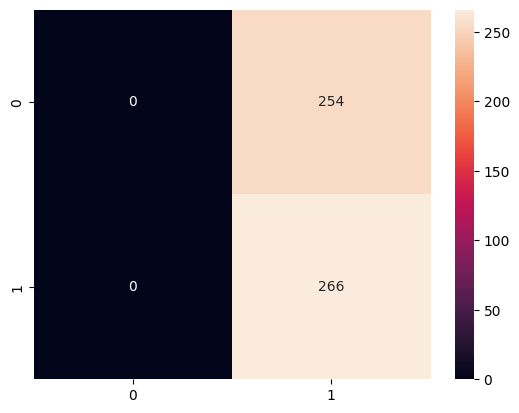

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test_resampled,aa.predict(X_test_resampled))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test_resampled,aa.predict(X_test_resampled)))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       254
           1       0.51      1.00      0.68       266

    accuracy                           0.51       520
   macro avg       0.26      0.50      0.34       520
weighted avg       0.26      0.51      0.35       520



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.svm import SVC
ss=SVC()
mm=ss.fit(X_train_resampled,y_train_resampled)
print(mm.intercept_)

[-0.35818045]


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train_resampled,mm.predict(X_train_resampled)))
print(accuracy_score(y_test_resampled,mm.predict(X_test_resampled)))

0.5640038498556305
0.5846153846153846


In [ ]:

print(confusion_matrix(y_test_resampled,mm.predict(X_test_resampled)))

[[111 143]
 [ 73 193]]


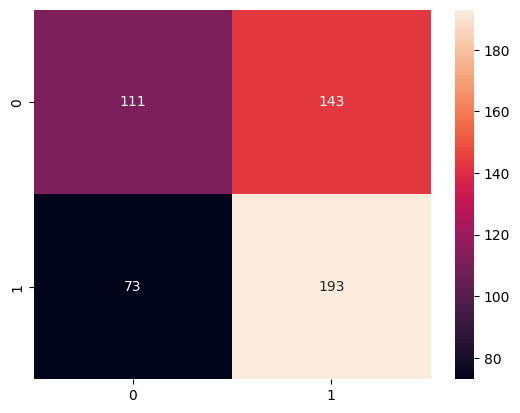

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test_resampled,mm.predict(X_test_resampled))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test_resampled,mm.predict(X_test_resampled)))


              precision    recall  f1-score   support

           0       0.60      0.44      0.51       254
           1       0.57      0.73      0.64       266

    accuracy                           0.58       520
   macro avg       0.59      0.58      0.57       520
weighted avg       0.59      0.58      0.58       520



In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
kk=lr.fit(X_train_resampled,y_train_resampled)
print(kk.intercept_,kk.coef_)

[-0.01460573] [[-1.46054188e-02  1.24013789e-03  2.37855492e-03 -5.70378476e-02
   7.18180769e-06 -1.48274171e-01  2.77767246e-03 -1.23514785e-01
  -8.57735004e-02 -2.95379695e-01 -4.24294957e-03  1.13192263e-02
   3.17520942e-03  1.54165793e-02  2.20223070e-04 -3.71197964e-02
  -1.30859156e-02  2.53373733e-02 -2.67703154e-02]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train_resampled,kk.predict(X_train_resampled)))
print(accuracy_score(y_test_resampled,kk.predict(X_test_resampled)))

0.706929740134745
0.7115384615384616


In [ ]:

print(confusion_matrix(y_test_resampled,kk.predict(X_test_resampled)))

[[172  82]
 [ 68 198]]


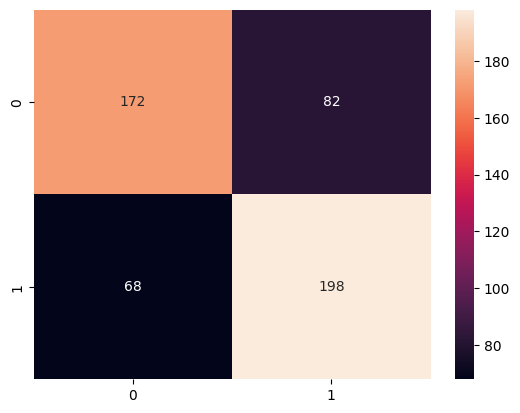

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test_resampled,kk.predict(X_test_resampled))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test_resampled,kk.predict(X_test_resampled)))


              precision    recall  f1-score   support

           0       0.72      0.68      0.70       254
           1       0.71      0.74      0.73       266

    accuracy                           0.71       520
   macro avg       0.71      0.71      0.71       520
weighted avg       0.71      0.71      0.71       520



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kk=KNeighborsClassifier()
nn=kk.fit(X_train_resampled,y_train_resampled)
print(nn.score(X_train_resampled,y_train_resampled))
print(nn.score(X_test_resampled,y_test_resampled))

0.8152069297401348
0.7365384615384616


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train_resampled,nn.predict(X_train_resampled)))
print(accuracy_score(y_test_resampled,nn.predict(X_test_resampled)))

0.8152069297401348
0.7365384615384616


[[172  82]
 [ 55 211]]


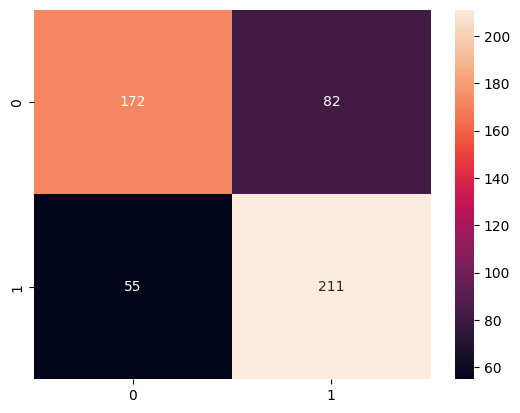

In [ ]:
print(confusion_matrix(y_test_resampled,nn.predict(X_test_resampled)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test_resampled,nn.predict(X_test_resampled))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test_resampled,nn.predict(X_test_resampled)))

              precision    recall  f1-score   support

           0       0.76      0.68      0.72       254
           1       0.72      0.79      0.75       266

    accuracy                           0.74       520
   macro avg       0.74      0.74      0.74       520
weighted avg       0.74      0.74      0.74       520



In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=9)
s=pca.fit_transform(X_resampled)
s=pd.DataFrame(data=s,columns=['x0','x1','x2','x3','x4','x5','x6','x7','x8'])
print(s)

                x0          x1         x2         x3         x4        x5  \
0     -5836.830973 -827.726520 -76.345221  17.038525  -9.942096 -1.703471   
1    -45593.819943 -811.286659  14.692346  30.934139 -25.745485 -3.605213   
2     -5479.823442 -825.517547   2.532564  21.343033  -3.900472  1.246039   
3      7551.170769 -829.725100 -62.063277 -19.272371  -3.790524 -3.605930   
4    -21279.817929 -817.398067  45.211036   9.279341   9.276671 -3.736875   
...            ...         ...        ...        ...        ...       ...   
2593   8364.540763  145.110063 -34.007904  21.486659  -3.345352 -1.629551   
2594   -538.743653 -630.051803  62.172159 -13.689096 -27.448888  2.942561   
2595 -62098.499958   43.763199  -3.240728 -16.990103  15.636054 -1.168647   
2596 -53640.286980  611.473761 -24.931530 -14.517792  20.235890  1.637599   
2597  40473.628836  359.290875  19.484954  11.642201 -20.244157  2.084001   

            x6        x7        x8  
0     1.177072  1.940921 -1.643298  
1

In [ ]:
s_train,s_test,y_train,y_test=train_test_split(s,y_resampled,test_size=0.2,random_state=30)
print("\nXtrain:")
print(s_train)
print("\nXtest:")
print(s_test)
print("\nytrain:")
print(y_train)
print("\nytest:")
print(y_test)


Xtrain:
                x0          x1         x2         x3         x4        x5  \
2063    593.305222 -478.990473 -28.549038  -9.615279  15.444658 -3.487106   
1475 -30397.258834  657.256419  83.664183  23.703197  -0.647956 -0.414079   
2510  31642.638873  379.709952  55.560523  -9.754301  10.562709 -2.781399   
2094  45862.695649  545.027183 -20.366833  16.023005   2.645968 -3.667958   
624  -33762.584931 -192.734703  24.599832  30.927704  -8.173440 -3.606170   
...            ...         ...        ...        ...        ...       ...   
919  -31446.484269  100.797259 -93.880435  21.269315  16.331626 -2.268423   
1164 -40796.390829  349.384486 -94.938678   5.640398 -11.083808  2.669671   
500   43599.361470 -345.991187   3.220322   5.601521 -11.149204 -2.021532   
421   -8277.660237 -405.178075  53.980088  -0.802888 -23.247244 -0.743719   
1829  28847.269634 -584.530763  -4.009284 -10.868793  15.306052 -0.825994   

            x6        x7        x8  
2063  1.916408 -1.372303  0.8

In [ ]:
from sklearn.linear_model import Perceptron
pp=Perceptron()
aa=pp.fit(s_train,y_train)
print(aa.intercept_,aa.coef_)

[-107.] [[ -9846.86037406 349309.25606321  26315.52156445 -41991.94699402
    6028.91810584  -5282.03430131   2095.22840104   1556.66332293
   -1294.78615284]]


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train,aa.predict(s_train)))
print(accuracy_score(y_test,aa.predict(s_test)))

0.4793070259865255
0.4403846153846154


[[118 136]
 [155 111]]


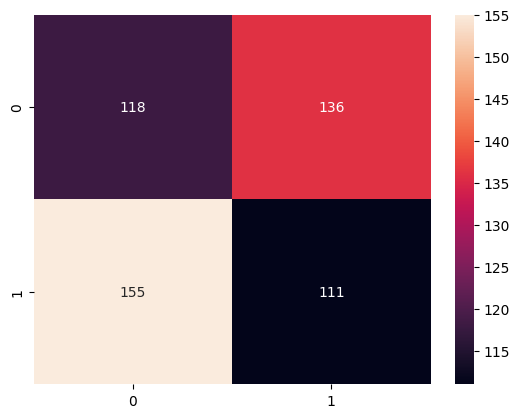

In [ ]:
print(confusion_matrix(y_test,aa.predict(s_test)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,aa.predict(s_test))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test,aa.predict(s_test)))

              precision    recall  f1-score   support

           0       0.43      0.46      0.45       254
           1       0.45      0.42      0.43       266

    accuracy                           0.44       520
   macro avg       0.44      0.44      0.44       520
weighted avg       0.44      0.44      0.44       520



In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
kk=lr.fit(s_train,y_train)
print(kk.intercept_,kk.coef_)

[-0.00406402] [[ 8.76048801e-06  1.45992786e-03  2.93693195e-03 -3.60694140e-02
   7.80247848e-03 -2.42614609e-01  1.15744537e-01  7.63221875e-02
  -6.41646368e-02]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train,kk.predict(s_train)))
print(accuracy_score(y_test,kk.predict(s_test)))

0.7006737247353224
0.676923076923077


[[169  85]
 [ 83 183]]


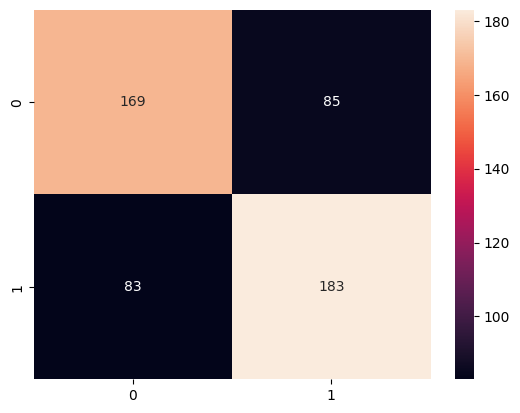

In [ ]:
print(confusion_matrix(y_test,kk.predict(s_test)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,kk.predict(s_test))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test,kk.predict(s_test)))

              precision    recall  f1-score   support

           0       0.67      0.67      0.67       254
           1       0.68      0.69      0.69       266

    accuracy                           0.68       520
   macro avg       0.68      0.68      0.68       520
weighted avg       0.68      0.68      0.68       520



In [ ]:
from sklearn.svm import SVC
ss=SVC()
mm=ss.fit(s_train,y_train)
print(mm.intercept_)

[-0.69834151]


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train,mm.predict(s_train)))
print(accuracy_score(y_test,mm.predict(s_test)))

0.5736284889316651
0.5903846153846154


[[112 142]
 [ 71 195]]


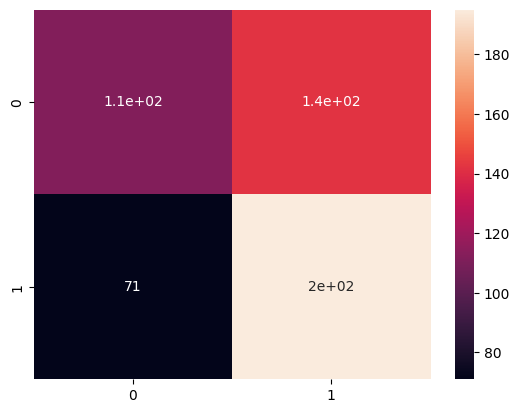

In [ ]:
print(confusion_matrix(y_test,mm.predict(s_test)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,mm.predict(s_test))
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
print(classification_report(y_test,mm.predict(s_test)))

              precision    recall  f1-score   support

           0       0.61      0.44      0.51       254
           1       0.58      0.73      0.65       266

    accuracy                           0.59       520
   macro avg       0.60      0.59      0.58       520
weighted avg       0.59      0.59      0.58       520



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kk=KNeighborsClassifier()
nn=kk.fit(s_train,y_train)
print(nn.score(s_train,y_train))
print(nn.score(s_test,y_test))

0.8152069297401348
0.7365384615384616


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_train,nn.predict(s_train)))
print(accuracy_score(y_test,nn.predict(s_test)))

0.8152069297401348
0.7365384615384616


[[172  82]
 [ 55 211]]


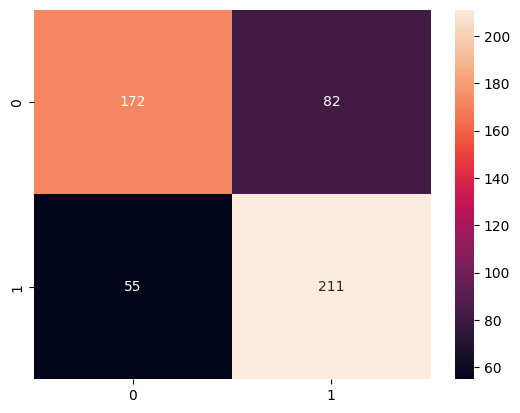

In [ ]:
print(confusion_matrix(y_test,nn.predict(s_test)))
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,nn.predict(s_test))
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test,nn.predict(s_test)))

              precision    recall  f1-score   support

           0       0.76      0.68      0.72       254
           1       0.72      0.79      0.75       266

    accuracy                           0.74       520
   macro avg       0.74      0.74      0.74       520
weighted avg       0.74      0.74      0.74       520



In [ ]:
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [ ]:
n_iterations=10
accuracy_scores_lr=[]
for _ in range(n_iterations):
    X_boot, y_boot = resample(X_resampled, y_resampled, replace=True, n_samples=len(X_resampled))
    X_train_boot, X_test_boot, y_train_boot, y_test_boot = train_test_split(X_boot, y_boot, test_size=0.2, random_state=42)
    lr = LogisticRegression()
    lr.fit(X_train_boot, y_train_boot)
    accuracy_scores_lr.append(accuracy_score(y_test_resampled, lr.predict(X_test_resampled)))

accuracy_scores_lr

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[0.7076923076923077,
 0.7076923076923077,
 0.7,
 0.6288461538461538,
 0.7038461538461539,
 0.6230769230769231,
 0.6173076923076923,
 0.7096153846153846,
 0.625,
 0.7115384615384616]

In [ ]:
n_iterations=10
accuracy_scores_svm=[]
for _ in range(n_iterations):
  X_boot, y_boot = resample(X_resampled, y_resampled, replace=True, n_samples=len(X_resampled))
  X_train_boot, X_test_boot, y_train_boot, y_test_boot = train_test_split(X_boot, y_boot, test_size=0.2, random_state=42)
  svm = SVC()
  svm.fit(X_train_boot, y_train_boot)
  accuracy_scores_svm.append(accuracy_score(y_test_resampled, svm.predict(X_test_resampled)))
  print(accuracy_scores_svm)

[0.5980769230769231]
[0.5980769230769231, 0.5865384615384616]
[0.5980769230769231, 0.5865384615384616, 0.5865384615384616]
[0.5980769230769231, 0.5865384615384616, 0.5865384615384616, 0.5596153846153846]
[0.5980769230769231, 0.5865384615384616, 0.5865384615384616, 0.5596153846153846, 0.5865384615384616]
[0.5980769230769231, 0.5865384615384616, 0.5865384615384616, 0.5596153846153846, 0.5865384615384616, 0.5788461538461539]
[0.5980769230769231, 0.5865384615384616, 0.5865384615384616, 0.5596153846153846, 0.5865384615384616, 0.5788461538461539, 0.5865384615384616]
[0.5980769230769231, 0.5865384615384616, 0.5865384615384616, 0.5596153846153846, 0.5865384615384616, 0.5788461538461539, 0.5865384615384616, 0.5673076923076923]
[0.5980769230769231, 0.5865384615384616, 0.5865384615384616, 0.5596153846153846, 0.5865384615384616, 0.5788461538461539, 0.5865384615384616, 0.5673076923076923, 0.573076923076923]
[0.5980769230769231, 0.5865384615384616, 0.5865384615384616, 0.5596153846153846, 0.586538461

In [ ]:
n_iterations=10
accuracy_scores_knn=[]
for _ in range(n_iterations):
  X_boot, y_boot = resample(X_resampled, y_resampled, replace=True, n_samples=len(X_resampled))
  X_train_boot, X_test_boot, y_train_boot, y_test_boot = train_test_split(X_boot, y_boot, test_size=0.2, random_state=42)
  knn = KNeighborsClassifier()
  knn.fit(X_train_boot, y_train_boot)
  accuracy_scores_knn.append(accuracy_score(y_test_resampled, knn.predict(X_test_resampled)))
  print(accuracy_scores_knn)

[0.7807692307692308]
[0.7807692307692308, 0.7673076923076924]
[0.7807692307692308, 0.7673076923076924, 0.7461538461538462]
[0.7807692307692308, 0.7673076923076924, 0.7461538461538462, 0.7692307692307693]
[0.7807692307692308, 0.7673076923076924, 0.7461538461538462, 0.7692307692307693, 0.7807692307692308]
[0.7807692307692308, 0.7673076923076924, 0.7461538461538462, 0.7692307692307693, 0.7807692307692308, 0.7884615384615384]
[0.7807692307692308, 0.7673076923076924, 0.7461538461538462, 0.7692307692307693, 0.7807692307692308, 0.7884615384615384, 0.7826923076923077]
[0.7807692307692308, 0.7673076923076924, 0.7461538461538462, 0.7692307692307693, 0.7807692307692308, 0.7884615384615384, 0.7826923076923077, 0.7692307692307693]
[0.7807692307692308, 0.7673076923076924, 0.7461538461538462, 0.7692307692307693, 0.7807692307692308, 0.7884615384615384, 0.7826923076923077, 0.7692307692307693, 0.7826923076923077]
[0.7807692307692308, 0.7673076923076924, 0.7461538461538462, 0.7692307692307693, 0.78076923

In [ ]:
n_iterations=10
accuracy_scores_perceptron=[]
for _ in range(n_iterations):
  X_boot, y_boot = resample(X_resampled, y_resampled, replace=True, n_samples=len(X_resampled))
  X_train_boot, X_test_boot, y_train_boot, y_test_boot = train_test_split(X_boot, y_boot, test_size=0.2, random_state=42)
  perceptron = Perceptron()
  perceptron.fit(X_train_boot, y_train_boot)
  accuracy_scores_perceptron.append(accuracy_score(y_test_resampled, perceptron.predict(X_test_resampled)))
  print(accuracy_scores_perceptron)

[0.5115384615384615]
[0.5115384615384615, 0.5115384615384615]
[0.5115384615384615, 0.5115384615384615, 0.48846153846153845]
[0.5115384615384615, 0.5115384615384615, 0.48846153846153845, 0.5115384615384615]
[0.5115384615384615, 0.5115384615384615, 0.48846153846153845, 0.5115384615384615, 0.5115384615384615]
[0.5115384615384615, 0.5115384615384615, 0.48846153846153845, 0.5115384615384615, 0.5115384615384615, 0.4423076923076923]
[0.5115384615384615, 0.5115384615384615, 0.48846153846153845, 0.5115384615384615, 0.5115384615384615, 0.4423076923076923, 0.48846153846153845]
[0.5115384615384615, 0.5115384615384615, 0.48846153846153845, 0.5115384615384615, 0.5115384615384615, 0.4423076923076923, 0.48846153846153845, 0.49038461538461536]
[0.5115384615384615, 0.5115384615384615, 0.48846153846153845, 0.5115384615384615, 0.5115384615384615, 0.4423076923076923, 0.48846153846153845, 0.49038461538461536, 0.5115384615384615]
[0.5115384615384615, 0.5115384615384615, 0.48846153846153845, 0.511538461538461

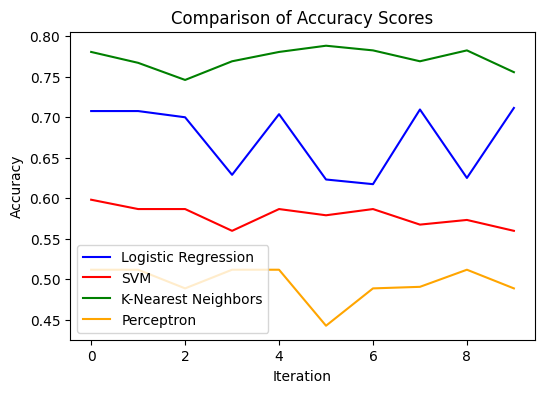

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
plt.plot(accuracy_scores_lr, label='Logistic Regression',color='blue')
plt.plot(accuracy_scores_svm, label='SVM',color='red')
plt.plot(accuracy_scores_knn, label='K-Nearest Neighbors',color='green')
plt.plot(accuracy_scores_perceptron, label='Perceptron',color='orange')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Comparison of Accuracy Scores')
plt.legend()
plt.show()